In [1]:
import warnings

# Suppress specific warning
warnings.filterwarnings("ignore", message="Graph is not fully connected, spectral embedding may not work as expected.", category=UserWarning)
# Suppress specific warning
warnings.filterwarnings("ignore", message="k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.", category=RuntimeWarning)
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS')
from methods import module_to_dict
from transitional_set import (construct_parent, construct_children, delete_children_connecting_edges, 
deleted_edges_to_nodes, merge_parent, delete_merged_nodes_connection, spectral_analysis, 
find_splitting_transitional_set, find_all_splitting_transitional_set, find_all_transitional_set)

In [3]:
!pwd
%cd /home/jovyan/work/COVID/transitional_set/Cell/Reciprocal_reciprocal
!pwd

/home/jovyan/work/COVID/transitional_set
/home/jovyan/work/COVID/transitional_set/Cell/Reciprocal_reciprocal
/home/jovyan/work/COVID/transitional_set/Cell/Reciprocal_reciprocal


read stage modules

In [4]:
module_ctrl = module_to_dict("/home/jovyan/work/COVID/parameter_tuning/reciprocal/knd_reciprocal/Cell/module_ctrl_0.7.json")
module_mild = module_to_dict("/home/jovyan/work/COVID/parameter_tuning/reciprocal/knd_reciprocal/Cell/module_mild_0.7.json")
module_severe = module_to_dict("/home/jovyan/work/COVID/parameter_tuning/reciprocal/knd_reciprocal/Cell/module_severe_0.7.json")

In [22]:
len(module_ctrl)

108

read pcc matrix

In [5]:
import pandas as pd
# import the PCC data
pcc_ctrl = pd.read_csv("/home/jovyan/work/COVID/results/pcc_control.csv", index_col=0)
pcc_mild = pd.read_csv("/home/jovyan/work/COVID/results/pcc_mild.csv", index_col=0)
pcc_severe = pd.read_csv("/home/jovyan/work/COVID/results/pcc_severe.csv", index_col=0)

pcc_ctrl

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AL627309.1,1.000000,0.355817,0.228245,0.445432,0.383732,0.251694,0.398397,-0.180755,0.211937,0.506467,...,-0.219447,0.089707,-0.075948,0.367428,0.444251,-0.049202,-0.164801,0.182791,0.104667,-0.109492
AL627309.4,0.355817,1.000000,-0.020470,0.560937,0.581096,0.312776,0.630832,-0.019241,0.363555,0.714848,...,-0.258779,0.110143,-0.136197,-0.158947,0.505242,-0.091704,-0.032674,0.054308,0.144107,0.010559
AL732372.1,0.228245,-0.020470,1.000000,0.074559,0.122271,0.018383,0.211597,0.053498,0.472034,0.054544,...,-0.174837,0.118689,0.040996,0.618964,0.250344,0.136197,0.064839,0.529239,0.321262,-0.244606
AL669831.2,0.445432,0.560937,0.074559,1.000000,0.342962,0.114597,0.372664,-0.112743,0.512556,0.649911,...,-0.050993,0.207640,0.117096,0.047820,0.563173,0.151045,-0.056025,0.008447,0.011003,0.040818
AL669831.5,0.383732,0.581096,0.122271,0.342962,1.000000,0.273196,0.748895,0.091072,0.314765,0.647219,...,-0.206828,0.171393,-0.163116,-0.092695,0.395888,0.014234,0.078203,0.192516,0.205644,0.267993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC023491.2,-0.049202,-0.091704,0.136197,0.151045,0.014234,-0.069917,0.019486,-0.033949,0.158318,0.049841,...,-0.021710,0.667373,0.029373,0.267866,0.015188,1.000000,0.053339,-0.085043,-0.091648,-0.038598
AC004556.1,-0.164801,-0.032674,0.064839,-0.056025,0.078203,-0.128880,-0.011038,0.372018,0.270079,-0.002586,...,-0.198202,-0.091038,-0.335324,-0.101195,-0.354331,0.053339,1.000000,-0.141557,-0.107665,0.348891
AC233755.2,0.182791,0.054308,0.529239,0.008447,0.192516,0.080272,0.211016,-0.149634,0.215407,0.047768,...,-0.226518,0.060870,0.063155,0.153132,0.390805,-0.085043,-0.141557,1.000000,0.672246,-0.300307
AC233755.1,0.104667,0.144107,0.321262,0.011003,0.205644,0.118125,0.207483,-0.106997,0.124246,0.076481,...,-0.163637,0.004468,0.016443,0.038674,0.253158,-0.091648,-0.107665,0.672246,1.000000,-0.207532


In [6]:
pcc_ctrl.name = "pcc_ctrl"
pcc_mild.name = "pcc_mild"
pcc_severe.name = "pcc_severe"


In [49]:
len(module_ctrl)

108

In [76]:
from igraph import Graph
module_ctrl_vs_mild_relation = Graph.Read_GraphML("module_ctrl_vs_mild_relation.graphml")
module_ctrl_vs_severe_relation = Graph.Read_GraphML("module_ctrl_vs_severe_relation.graphml")
module_mild_vs_severe_relation = Graph.Read_GraphML("module_mild_vs_severe_relation.graphml")

In [77]:
print(len(module_ctrl_vs_mild_relation.vs))
print(len(module_ctrl_vs_severe_relation.vs))
print(len(module_mild_vs_severe_relation.vs))

19
10
20


construct the parent graph (weighted undirected connected), with given pcc theshold

In [51]:
len(module_ctrl['module_ctrl_29'])

44

In [52]:
for i in module_ctrl_vs_mild_relation.vs["name"]:
    print(i)

module_ctrl_0
module_mild_1
module_ctrl_1
module_mild_0
module_ctrl_4
module_mild_6
module_mild_15
module_mild_24
module_mild_43
module_ctrl_8
module_ctrl_14
module_mild_2
module_ctrl_3
module_mild_4
module_ctrl_36
module_ctrl_19
module_mild_18
module_ctrl_29
module_mild_3


In [53]:
parent_graph = construct_parent(parent_name="module_ctrl_29", stage_module=module_ctrl, pcc_matrix=pcc_ctrl, pcc_theshold=0.5)
print(parent_graph.summary())

IGRAPH UNW- 44 945 -- 
+ attr: name (v), weight (e)


find overlapped children genes

In [54]:
children_overlapped_parts = construct_children(parent_name="module_ctrl_29", parent_graph=parent_graph, relation_graph=module_ctrl_vs_mild_relation, stage_module=module_mild)
print(children_overlapped_parts)

{'module_mild_3': {'KCNMB1', 'ATP8B4', 'CLEC10A', 'ST6GAL1', 'LIMD2', 'MEF2C', 'CORO1A', 'PKIB', 'ENTPD1', 'NRM', 'KLHL5', 'PAK1', 'ADAM28', 'PEA15', 'NLRP3', 'STK38L', 'CCND2', 'LGALS2', 'ITGA4'}}


In [55]:
for i in children_overlapped_parts:
    print(len(children_overlapped_parts[i]))

19


merge the parts of the parent overlapped with children into individual nodes

In [56]:
mg = merge_parent(parent_graph=parent_graph, children_overlapped_parts=children_overlapped_parts)
mg.summary()

'IGRAPH UNW- 26 325 -- \n+ attr: name (v), weight (e)'

In [57]:
print(mg.vs["name"])

['DENND1B', 'MCOLN2', 'PHF19', 'SPECC1', 'CST7', 'TCF4', 'CDK6', 'BCL11A', 'GPR183', 'BCL2', 'GPR132', 'GAS6', 'ZNF652', 'AL138899.1', 'RASSF2', 'S1PR2', 'SH3KBP1', 'RUNX3', 'BASP1', 'PTPN7', 'EMB', 'ACAP1', 'SRD5A1', 'ADAM8', 'SERPINB9', 'module_mild_3']


In [58]:
print(sorted(mg.es["weight"], reverse=True)[:30])

[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 1.0, 1.0, 1.0, 1.0, 1.0]


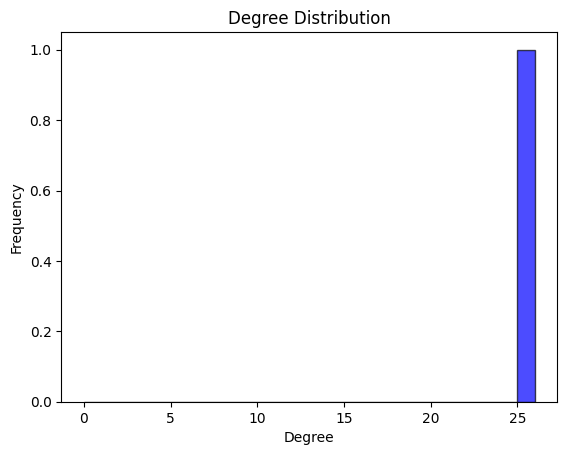

In [59]:
import matplotlib.pyplot as plt
# Get the degree sequence of the graph
degree_sequence = mg.degree()

# Plot the degree distribution
plt.hist(degree_sequence, bins=range(max(degree_sequence) + 2), density=True, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')
plt.show()

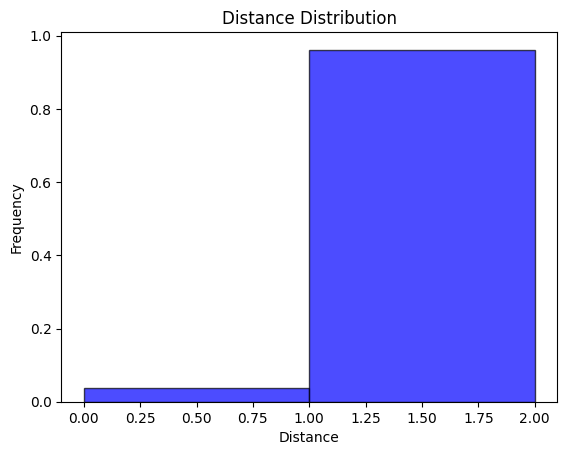

In [60]:
# Get all pairs of nodes' distances
distances = mg.distances()

# Flatten the distances matrix
all_distances = [distance for distances_row in distances for distance in distances_row if distance != float('inf')]

# Plot the distance distribution
plt.hist(all_distances, bins=range(int(max(all_distances)) + 2), density=True, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution')
plt.show()

In [36]:
# from itertools import combinations

# # Find all neighboring vertices
# neighbors = module_I_vs_severe_relation.neighbors("module_I_27")
# related = [module_I_vs_severe_relation.vs.find(id)["name"] for id in neighbors]

# for i in related:
#     # List of nodes you want to connect
#     nodes_to_connect = set(module_I_27_graph.vs["name"]) & set(module_severe[i])
    
#     # Add edges between all pairs of nodes
#     for pair in combinations(nodes_to_connect, 2):
#         # Check if the edge already exists
#         if not module_I_27_graph.are_connected(pair[0], pair[1]):
#             # If not, add the edge
#             module_I_27_graph.add_edge(pair[0], pair[1])

# # Now, 'g' is fully connected with all nodes in 'nodes_to_connect'
# print(module_I_27_graph.summary())

try spectral analysis clustering

In [37]:
# deleted_edge_list = list()
# for edge in g.es:
#     s = edge.source_vertex
#     t = edge.target_vertex
#     if s["color"] != t["color"]:
#         if s["name"].split("_")[0] == "module" and t["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[s["name"]]:
#                 for j in children_overlapped_parts[t["name"]]:
#                     if parent_graph.are_connected(i, j):
#                         deleted_edge_list.append((i, j))
#         # else:
#         #     continue
#         elif s["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[s["name"]]:
#                 if parent_graph.are_connected(t["name"], i):
#                     deleted_edge_list.append((t["name"], i))
#         elif t["name"].split("_")[0] == "module":
#             for i in children_overlapped_parts[t["name"]]:
#                 if parent_graph.are_connected(s["name"], i):
#                     deleted_edge_list.append((s["name"], i))
#         else:
#             deleted_edge_list.append((s["name"], t["name"]))
                
            
    

In [38]:
deleted_edge_list = delete_children_connecting_edges(parent_graph=parent_graph, children_overlapped_parts=children_overlapped_parts)
len(deleted_edge_list)

0

In [39]:
nodes = deleted_edges_to_nodes(deleted_edge_list=deleted_edge_list)
print(len(nodes))

0


In [40]:
dg = delete_merged_nodes_connection(merged_parent_graph=mg, children_overlapped_parts=children_overlapped_parts)
dg.summary()

'IGRAPH UNW- 26 325 -- \n+ attr: name (v), weight (e)'

In [41]:
labels = spectral_analysis(deleted_merged_nodes_connections_parent_graph=dg, n_clusters=3)
print(labels)

[2 2 2 0 2 0 1 2 2 2 0 2 2 1 2 2 1 2 1 0 1 2 2 2 2 2]


In [42]:
nodes = find_splitting_transitional_set(parent_name="module_I_22", first_stage_module=module_I, second_stage_module=module_severe, relation_graph=module_I_vs_severe_relation, pcc_matrix=pcc_I, pcc_theshold=0.7)
print(nodes[:10])

NameError: name 'module_I' is not defined

In [ ]:
all_nodes_split = find_all_splitting_transitional_set(first_stage_module=module_I, second_stage_module=module_severe, relation_graph=module_I_vs_severe_relation, pcc_matrix=pcc_I, pcc_theshold=0.7)
print(len(all_nodes_split))

In [ ]:
all_nodes_merge = find_all_splitting_transitional_set(first_stage_module=module_severe, second_stage_module=module_mild, relation_graph=modulemild_vs_severe_relation, pcc_matrix=pcc_severe, pcc_theshold=0.7)
print(len(all_nodes_merge))

final function works

In [78]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_ctrl, second_stage_module=module_mild, relation_graph=module_ctrl_vs_mild_relation, first_pcc_matrix=pcc_ctrl, second_pcc_matrix=pcc_mild, pcc_theshold=0.5)
print(len(mutual_nodes))

0


In [80]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_ctrl, second_stage_module=module_severe, relation_graph=module_ctrl_vs_severe_relation, first_pcc_matrix=pcc_ctrl, second_pcc_matrix=pcc_severe, pcc_theshold=0.5)
print(len(mutual_nodes))

22


In [81]:
mutual_nodes = find_all_transitional_set(first_stage_module=module_mild, second_stage_module=module_severe, relation_graph=module_mild_vs_severe_relation, first_pcc_matrix=pcc_mild, second_pcc_matrix=pcc_severe, pcc_theshold=0.5)
print(len(mutual_nodes))

80


In [82]:
print(list(mutual_nodes)[:10])

['TMEM251', 'HSPA8', 'PDCD10', 'GPAA1', 'CD93', 'CORO1A', 'RHEB', 'MLX', 'MITF', 'PSMC1']
